In [ ]:
!pip install --quiet holidays

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Validações, eliminar primeira coluna que não tem informações

#df1 = pd.read_excel('../data/validaciones/val_enero.xlsx',header=6)
#df2 = pd.read_excel('../data/validaciones/val_febrero.xlsx',header=6)
#df3 = pd.read_excel('../data/validaciones/val_marzo.xlsx',header=6)
#df4 = pd.read_excel('../data/validaciones/val_abril.xlsx',header=6)
#df5 = pd.read_excel('../data/validaciones/val_mayo.xlsx',header=6)
#df6 = pd.read_excel('../data/validaciones/val_junio.xlsx',header=6)
#df7 = pd.read_excel('../data/validaciones/val_julio.xlsx',header=6)
#df8 = pd.read_excel('../data/validaciones/val_agosto.xlsx',header=6)
#df9 = pd.read_excel('../data/validaciones/val_septiembre.xlsx',header=6)
df10 = pd.read_excel('../data/validaciones/val_octubre.xlsx',header=6)
df11 = pd.read_excel('../data/validaciones/val_noviembre.xlsx',header=6)


# Saidas das estações

#df12 = pd.read_excel('../data/salidas/salidas_enero.xlsx',header=6)
#df13 = pd.read_excel('../data/salidas/salidas_febrero.xlsx',header=6)
#df14 = pd.read_excel('../data/salidas/salidas_marzo.xlsx',header=6)
#df15 = pd.read_excel('../data/salidas/salidas_abril.xlsx',header=6)
#df16 = pd.read_excel('../data/salidas/salidas_mayo.xlsx',header=6)
#df17 = pd.read_excel('../data/salidas/salidas_junio.xlsx',header=6)
#df18 = pd.read_excel('../data/salidas/salidas_julio.xlsx',header=6)
#df19 = pd.read_excel('../data/salidas/salidas_agosto.xlsx',header=6)
#df20 = pd.read_excel('../data/salidas/salidas_septiembre.xlsx',header=6)
df21 = pd.read_excel('../data/salidas/salidas_octubre.xlsx',header=6)
df22 = pd.read_excel('../data/salidas/salidas_noviembre.xlsx',header=6)


**DATA CLEANING**

In [5]:
print(df10.shape, df11.shape)
print(df21.shape, df22.shape)
print(df22.shape[0]*30)

(78522, 38) (78522, 38)
(49824, 36) (49975, 35)
1499250


Vamos olhar as validações (entradas ao sistema) de outubro e novembro de 2025:

In [6]:
df10.head(3)

,Unnamed: 0,Fase,Línea,Estación,Acceso de Estación,Intervalo,2025-10-01 00:00:00,2025-10-02 00:00:00,2025-10-03 00:00:00,2025-10-04 00:00:00,...,2025-10-23 00:00:00,2025-10-24 00:00:00,2025-10-25 00:00:00,2025-10-26 00:00:00,2025-10-27 00:00:00,2025-10-28 00:00:00,2025-10-29 00:00:00,2025-10-30 00:00:00,2025-10-31 00:00:00,Total general
0,NaN,Dual,(10006) M84-C84,(11474) MC84_V3,(61413) C004|21 Ángeles A - 2,09:00:00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,NaN,Dual,(10006) M84-C84,(11474) MC84_V3,(71386) BD-019A|K7 - CL73 S/N A,14:30:00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,NaN,Dual,(10006) M84-C84,(11474) MC84_V3,(71386) BD-019A|K7 - CL73 S/N A,16:30:00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [7]:
df11.head(3)

,Unnamed: 0,Fase,Línea,Estación,Acceso de Estación,Intervalo,2025-11-01 00:00:00,2025-11-02 00:00:00,2025-11-03 00:00:00,2025-11-04 00:00:00,...,2025-11-23 00:00:00,2025-11-24 00:00:00,2025-11-25 00:00:00,2025-11-26 00:00:00,2025-11-27 00:00:00,2025-11-28 00:00:00,2025-11-29 00:00:00,2025-11-30 00:00:00,2025-12-01 00:00:00,Total general
0,NaN,Dual,(10006) M84-C84,(12296) MC84_V4,(71476) 195B03|Av Suba - K110A.,07:00:00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,1
1,NaN,Dual,(10006) M84-C84,(12296) MC84_V4,(73636) 081A00|AC85 - KR16A,07:45:00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,1
2,NaN,Dual,(10006) M84-C84,(12387) MC84_V5,(0) (Unknown),07:30:00,0.0,0.0,0.0,0.0,...,0.0,0.0,18.0,0.0,0.0,0.0,0.0,0.0,NaN,18


In [8]:
print(df10['Fase'].unique())
print(df11['Fase'].unique())

['Dual' 'Fase 3' 'Fase 2' 'Fase 1' nan 'Total general']
['Dual' 'Fase 3' 'Fase 2' 'Fase 1' nan 'Total general']


As tabelas das validações dos meses com menos de 31 dias contem colunas correspondentes aos primeiros dias do mês seguinte que precisam ser excluidas, além da primeira e última colunas. Além disso, parece que o formato (número de colunas, nombre das colunas, etc) dessas duas tabelas, e por extensão o de todas as tabelas fornecidas por TM é uniforme. O formato das tabelas é 'wide' e precisamos do formato 'long'.

Já é evidente que tem registro de linhas da Fase 'Dual' que corresponden a ônibus que passam também por faixas não exclusivas e têm paradas na rua. Só interessam as linhas que passam pelas faixas exclusivas de TM e param apenas nas estações. Também há valores 'nan' e 'Total general' na coluna Fase, o que deve estar errado.

In [9]:
df11[df11.Fase == 'Total general']

,Unnamed: 0,Fase,Línea,Estación,Acceso de Estación,Intervalo,2025-11-01 00:00:00,2025-11-02 00:00:00,2025-11-03 00:00:00,2025-11-04 00:00:00,...,2025-11-23 00:00:00,2025-11-24 00:00:00,2025-11-25 00:00:00,2025-11-26 00:00:00,2025-11-27 00:00:00,2025-11-28 00:00:00,2025-11-29 00:00:00,2025-11-30 00:00:00,2025-12-01 00:00:00,Total general
78521,NaN,Total general,Total general,Total general,Total general,Total general,1399384.0,712181.0,615667.0,2081497.0,...,674491.0,1939483.0,1993499.0,1996838.0,1971135.0,1989708.0,1491261.0,761449.0,0.0,48044409


In [10]:
df11[df11['Fase'].isnull()]

,Unnamed: 0,Fase,Línea,Estación,Acceso de Estación,Intervalo,2025-11-01 00:00:00,2025-11-02 00:00:00,2025-11-03 00:00:00,2025-11-04 00:00:00,...,2025-11-23 00:00:00,2025-11-24 00:00:00,2025-11-25 00:00:00,2025-11-26 00:00:00,2025-11-27 00:00:00,2025-11-28 00:00:00,2025-11-29 00:00:00,2025-11-30 00:00:00,2025-12-01 00:00:00,Total general
53145,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
53146,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
53147,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
53148,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
53149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78516,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
78517,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
78518,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
78519,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


Tem mais de 25 mil linhas totalmente nulas em novembro (caso similar para outubro). O valor Fase = 'Total general' corresponde a uma linha de sumarização. Vamos eliminar as linhas com Fase 'Dual', 'nan', e 'Total general' e conservar as outras:

In [11]:
df10 = df10[df10['Fase'].isin(['Fase 1', 'Fase 2', 'Fase 3'])]
df11 = df11[df11['Fase'].isin(['Fase 1', 'Fase 2', 'Fase 3'])]
print(df10.shape)
print(df11.shape)

(30168, 38)
(30132, 38)


Agora vamos mudar os dataframes ao formato 'long':

In [12]:
df10_long = df10.melt(id_vars = ['Fase', 'Línea', 'Estación', 'Acceso de Estación', 'Intervalo'],
                      value_vars = df10.columns[6:-1], var_name = 'Fecha', value_name = 'Validaciones')
print('Tamanho tabela outubro:', df10_long.shape)

df11_long = df11.melt(id_vars = ['Fase', 'Línea', 'Estación', 'Acceso de Estación', 'Intervalo'],
                      value_vars = df11.columns[6:-2], var_name = 'Fecha', value_name = 'Validaciones')
print('Tamanho tabela novembro:', df11_long.shape)

df10_long.head(3)



Tamanho tabela outubro: (935208, 7)
Tamanho tabela novembro: (903960, 7)


,Fase,Línea,Estación,Acceso de Estación,Intervalo,Fecha,Validaciones
0,Fase 3,(11) Zona K Calle 26,(06001) Modelia,(01) Acceso Peatonal Oriental,04:15:00,2025-10-01 00:00:00,0.0
1,Fase 3,(11) Zona K Calle 26,(06001) Modelia,(01) Acceso Peatonal Oriental,04:30:00,2025-10-01 00:00:00,1.0
2,Fase 3,(11) Zona K Calle 26,(06001) Modelia,(01) Acceso Peatonal Oriental,04:45:00,2025-10-01 00:00:00,8.0


Vamos ver os tipos de dados:

In [13]:
df10_long.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 935208 entries, 0 to 935207
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Fase                935208 non-null  object 
 1   Línea               935208 non-null  object 
 2   Estación            935208 non-null  object 
 3   Acceso de Estación  935208 non-null  object 
 4   Intervalo           935208 non-null  object 
 5   Fecha               935208 non-null  object 
 6   Validaciones        935208 non-null  float64
dtypes: float64(1), object(6)
memory usage: 49.9+ MB


As colunas Intervalo e Data deveriam ser de tipo timestamp ou datetime. E é mais útil que as duas estejam na mesma coluna. Mas antes de ajeitar isso, vamos concatenar os dataframes:

In [14]:
# Juntar os dataframes
df_val = pd.concat([df10_long, df11_long], axis=0)
print(df_val.shape)

(1839168, 7)


In [15]:
df_val.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1839168 entries, 0 to 903959
Data columns (total 7 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Fase                object 
 1   Línea               object 
 2   Estación            object 
 3   Acceso de Estación  object 
 4   Intervalo           object 
 5   Fecha               object 
 6   Validaciones        float64
dtypes: float64(1), object(6)
memory usage: 112.3+ MB


In [16]:
# Mudar tipo de dado da data e hora de object a datetime
# dt.normalize() é para garantir que todas as horas estão na meia noite 00:00:00
df_val['Fecha'] = df_val['Fecha'].astype(str).str.split(' ').str[0].str.strip()
delta_horas = df_val['Intervalo'].astype(str).str.strip()
df_val['Fecha'] = pd.to_datetime(df_val['Fecha'] + ' ' + delta_horas, format = '%Y-%m-%d %H:%M:%S')
df_val.drop('Intervalo', axis=1, inplace=True)

df_val.head()

,Fase,Línea,Estación,Acceso de Estación,Fecha,Validaciones
0,Fase 3,(11) Zona K Calle 26,(06001) Modelia,(01) Acceso Peatonal Oriental,2025-10-01 04:15:00,0.0
1,Fase 3,(11) Zona K Calle 26,(06001) Modelia,(01) Acceso Peatonal Oriental,2025-10-01 04:30:00,1.0
2,Fase 3,(11) Zona K Calle 26,(06001) Modelia,(01) Acceso Peatonal Oriental,2025-10-01 04:45:00,8.0
3,Fase 3,(11) Zona K Calle 26,(06001) Modelia,(01) Acceso Peatonal Oriental,2025-10-01 05:00:00,18.0
4,Fase 3,(11) Zona K Calle 26,(06001) Modelia,(01) Acceso Peatonal Oriental,2025-10-01 05:15:00,31.0


In [17]:
df_val.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1839168 entries, 0 to 903959
Data columns (total 6 columns):
 #   Column              Dtype         
---  ------              -----         
 0   Fase                object        
 1   Línea               object        
 2   Estación            object        
 3   Acceso de Estación  object        
 4   Fecha               datetime64[ns]
 5   Validaciones        float64       
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 98.2+ MB


In [18]:
# Verificar linhas duplicadas
print('Linhas repetidas:', df_val.duplicated().sum())

Linhas repetidas: 0


In [19]:
# Verificar outros nulos
df_val.isna().sum()

Fase                  0
Línea                 0
Estación              0
Acceso de Estación    0
Fecha                 0
Validaciones          0
dtype: int64

DATAFRAMES DAS SAÍDAS:

In [20]:
df21.head(3)

,Linea,Estacion,Acceso_Estacion,Intervalo,_2025_10_01,_2025_10_02,_2025_10_03,_2025_10_04,_2025_10_05,_2025_10_06,...,_2025_10_23,_2025_10_24,_2025_10_25,_2025_10_26,_2025_10_27,_2025_10_28,_2025_10_29,_2025_10_30,_2025_10_31,total_general
0,(11)Zona K Calle 26,(06000)Portal El Dorado - C.C. NUESTRO BOGOTA,(01) PLAT2 ALIM-DESAL FONTIBÓN/FONTIBÓN CENTRO...,00:00:00,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,(11)Zona K Calle 26,(06000)Portal El Dorado - C.C. NUESTRO BOGOTA,(01) PLAT2 ALIM-DESAL FONTIBÓN/FONTIBÓN CENTRO...,00:15:00,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,(11)Zona K Calle 26,(06000)Portal El Dorado - C.C. NUESTRO BOGOTA,(01) PLAT2 ALIM-DESAL FONTIBÓN/FONTIBÓN CENTRO...,00:30:00,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
df22.head(3)

,Linea,Estacion,Acceso_Estacion,Intervalo,_2025_11_01,_2025_11_02,_2025_11_03,_2025_11_04,_2025_11_05,_2025_11_06,...,_2025_11_22,_2025_11_23,_2025_11_24,_2025_11_25,_2025_11_26,_2025_11_27,_2025_11_28,_2025_11_29,_2025_11_30,total_general
0,(11)Zona K Calle 26,(06000)Portal El Dorado - C.C. NUESTRO BOGOTA,(01) PLAT2 ALIM-DESAL FONTIBÓN/FONTIBÓN CENTRO...,00:00:00,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,(11)Zona K Calle 26,(06000)Portal El Dorado - C.C. NUESTRO BOGOTA,(01) PLAT2 ALIM-DESAL FONTIBÓN/FONTIBÓN CENTRO...,00:15:00,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,(11)Zona K Calle 26,(06000)Portal El Dorado - C.C. NUESTRO BOGOTA,(01) PLAT2 ALIM-DESAL FONTIBÓN/FONTIBÓN CENTRO...,00:30:00,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


As tabelas de saidas também tem estrutura uniforme. Agora vamos fazer com as tabelas das saidas um processo similar ao que foi feito com as tabelas das validações:

In [22]:
# Mudar ao formato 'long'
df21_long = df21.melt(id_vars = ['Linea', 'Estacion', 'Acceso_Estacion', 'Intervalo'], value_vars = df21.columns[4:-1], var_name = 'Fecha', value_name = 'Salidas')
df22_long = df22.melt(id_vars = ['Linea', 'Estacion', 'Acceso_Estacion', 'Intervalo'], value_vars = df22.columns[4:-1], var_name = 'Fecha', value_name = 'Salidas')
print(df21_long.shape)
print(df22_long.shape)

# Juntar as tabelas
df_sai = pd.concat([df21_long, df22_long], axis=0)
print(df_sai.shape)
df_sai.head(3)

(1544544, 6)
(1499250, 6)
(3043794, 6)


,Linea,Estacion,Acceso_Estacion,Intervalo,Fecha,Salidas
0,(11)Zona K Calle 26,(06000)Portal El Dorado - C.C. NUESTRO BOGOTA,(01) PLAT2 ALIM-DESAL FONTIBÓN/FONTIBÓN CENTRO...,00:00:00,_2025_10_01,0
1,(11)Zona K Calle 26,(06000)Portal El Dorado - C.C. NUESTRO BOGOTA,(01) PLAT2 ALIM-DESAL FONTIBÓN/FONTIBÓN CENTRO...,00:15:00,_2025_10_01,0
2,(11)Zona K Calle 26,(06000)Portal El Dorado - C.C. NUESTRO BOGOTA,(01) PLAT2 ALIM-DESAL FONTIBÓN/FONTIBÓN CENTRO...,00:30:00,_2025_10_01,0


In [23]:
df_sai.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3043794 entries, 0 to 1499249
Data columns (total 6 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   Linea            object
 1   Estacion         object
 2   Acceso_Estacion  object
 3   Intervalo        object
 4   Fecha            object
 5   Salidas          int64 
dtypes: int64(1), object(5)
memory usage: 162.6+ MB


In [24]:
# Verificar nulos
df_sai.isnull().sum()

Linea                0
Estacion             0
Acceso_Estacion    186
Intervalo            0
Fecha                0
Salidas              0
dtype: int64

In [25]:
# Olhar as linhas com nulos
acceso_null = df_sai[df_sai['Acceso_Estacion'].isnull()]
acceso_null

,Linea,Estacion,Acceso_Estacion,Intervalo,Fecha,Salidas
15368,(31)Zona F Av. Américas,(01000)INICIALIZACION,NaN,14:45:00,_2025_10_01,0
15369,(31)Zona F Av. Américas,(01000)INICIALIZACION,NaN,15:00:00,_2025_10_01,0
15370,(31)Zona F Av. Américas,(01000)INICIALIZACION,NaN,15:15:00,_2025_10_01,0
15371,(31)Zona F Av. Américas,(01000)INICIALIZACION,NaN,15:30:00,_2025_10_01,0
15372,(31)Zona F Av. Américas,(01000)INICIALIZACION,NaN,15:45:00,_2025_10_01,0
...,...,...,...,...,...,...
1510089,(31)Zona F Av. Américas,(01000)INICIALIZACION,NaN,15:00:00,_2025_10_31,0
1510090,(31)Zona F Av. Américas,(01000)INICIALIZACION,NaN,15:15:00,_2025_10_31,0
1510091,(31)Zona F Av. Américas,(01000)INICIALIZACION,NaN,15:30:00,_2025_10_31,0
1510092,(31)Zona F Av. Américas,(01000)INICIALIZACION,NaN,15:45:00,_2025_10_31,0


In [26]:
print(acceso_null['Estacion'].unique())
print(acceso_null['Salidas'].unique())

['(01000)INICIALIZACION']
[0]


Embora pode se tratar de uma estação com só um acesso sem nome, o nome mesmo da estação '(01000)INICIALIZACION' (inicialização) é estranho, e além disso não apresenta saidas. Preciso pesquisar sobre isso. Por enquanto vou manter essas linhas no dataframe.

Tem que juntar as colunas Intervalo e Fecha(Data), e mudar o formato a datetime:

In [27]:
data = df_sai['Fecha'].str.lstrip('_').str.replace('_', '-')
hora = df_sai['Intervalo'].str.strip()
df_sai['Fecha'] = pd.to_datetime(data + ' ' + hora, format = '%Y-%m-%d %H:%M:%S')
df_sai.drop('Intervalo', axis=1, inplace=True)
print(df_sai.shape)

df_sai.head()

(3043794, 5)


,Linea,Estacion,Acceso_Estacion,Fecha,Salidas
0,(11)Zona K Calle 26,(06000)Portal El Dorado - C.C. NUESTRO BOGOTA,(01) PLAT2 ALIM-DESAL FONTIBÓN/FONTIBÓN CENTRO...,2025-10-01 00:00:00,0
1,(11)Zona K Calle 26,(06000)Portal El Dorado - C.C. NUESTRO BOGOTA,(01) PLAT2 ALIM-DESAL FONTIBÓN/FONTIBÓN CENTRO...,2025-10-01 00:15:00,0
2,(11)Zona K Calle 26,(06000)Portal El Dorado - C.C. NUESTRO BOGOTA,(01) PLAT2 ALIM-DESAL FONTIBÓN/FONTIBÓN CENTRO...,2025-10-01 00:30:00,0
3,(11)Zona K Calle 26,(06000)Portal El Dorado - C.C. NUESTRO BOGOTA,(01) PLAT2 ALIM-DESAL FONTIBÓN/FONTIBÓN CENTRO...,2025-10-01 00:45:00,0
4,(11)Zona K Calle 26,(06000)Portal El Dorado - C.C. NUESTRO BOGOTA,(01) PLAT2 ALIM-DESAL FONTIBÓN/FONTIBÓN CENTRO...,2025-10-01 01:00:00,0


In [28]:
print('Linhas duplicadas:', df_sai.duplicated().sum())

Linhas duplicadas: 0


**EDA**

In [29]:
df_val['Validaciones'].describe()

count    1.839168e+06
mean     3.679980e+01
std      8.560002e+01
min      0.000000e+00
25%      0.000000e+00
50%      3.000000e+00
75%      3.800000e+01
max      1.818000e+03
Name: Validaciones, dtype: float64

O valor máximo de 1818 validações chama a atenção:

In [30]:
df_val[df_val['Validaciones'] == 1818]

,Fase,Línea,Estación,Acceso de Estación,Fecha,Validaciones
280307,Fase 2,(31) Zona F Av. Américas,(05000) Portal Américas,(23) Acceso Peatonal,2025-11-10 06:30:00,1818.0


In [31]:
df_val.sort_values(by='Validaciones', ascending=False).head(10)

,Fase,Línea,Estación,Acceso de Estación,Fecha,Validaciones
280307,Fase 2,(31) Zona F Av. Américas,(05000) Portal Américas,(23) Acceso Peatonal,2025-11-10 06:30:00,1818.0
340569,Fase 2,(31) Zona F Av. Américas,(05000) Portal Américas,(23) Acceso Peatonal,2025-11-12 06:00:00,1794.0
280308,Fase 2,(31) Zona F Av. Américas,(05000) Portal Américas,(23) Acceso Peatonal,2025-11-10 06:45:00,1784.0
370701,Fase 2,(31) Zona F Av. Américas,(05000) Portal Américas,(23) Acceso Peatonal,2025-11-13 06:00:00,1780.0
564483,Fase 1,(35) Zona D Calle 80,(04000) Cabecera Calle 80,(16) Acceso Peatonal,2025-11-19 07:15:00,1779.0
845805,Fase 3,(12) Zona L Carrera 10,(10000) Portal 20 de Julio,(01) ALIMENTACIÓN JUAN REY/ALTAMIRA/TIHUAQUE/L...,2025-10-29 07:30:00,1779.0
732806,Fase 2,(31) Zona F Av. Américas,(05002) Tintal,(03) Acceso Sur,2025-11-25 06:30:00,1720.0
732805,Fase 2,(31) Zona F Av. Américas,(05002) Tintal,(03) Acceso Sur,2025-11-25 06:15:00,1705.0
280305,Fase 2,(31) Zona F Av. Américas,(05000) Portal Américas,(23) Acceso Peatonal,2025-11-10 06:00:00,1656.0
914213,Fase 2,(31) Zona F Av. Américas,(05000) Portal Américas,(23) Acceso Peatonal,2025-10-31 05:45:00,1654.0


Um valor de 1818 validações em um intervalo de 15 minutos parece atípico, mas se olharmos os 10 maiores valores, pode-se ver que não é  um outlier. Sete desses valores correspondem a um 'portal', que não é uma estação qualquer (os portais são muito mais grandes que uma estação), e num horário bem cedo de manhã que é horario de pico (~ 6:30 am). Também, era de se esperar que esses números altos ocorressem entre segunda e sexta feiras. Agora vamos olhar um histograma das validações:

<Axes: >

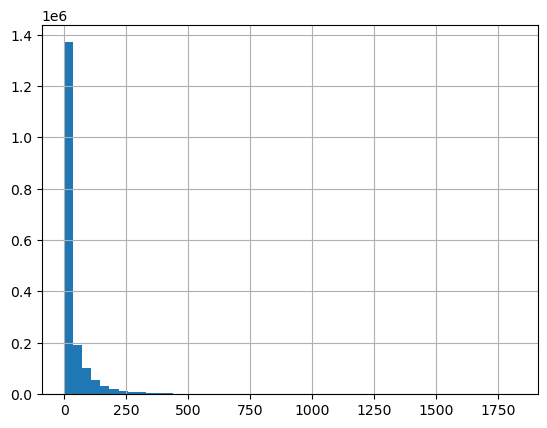

In [32]:
df_val['Validaciones'].hist(bins=50)

Tem uma forte assimetria à direita. Para visualizar melhor a distribuição, vamos considerar só valores menores a 250 e tirar os zeros:

<Axes: >

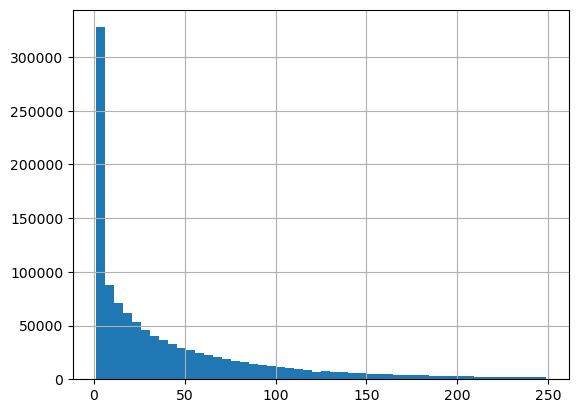

In [33]:
df_val[(df_val['Validaciones'] < 250) & (df_val['Validaciones'] != 0)]['Validaciones'].hist(bins=50)

Agora vamos olhar as saidas:

In [34]:
df_sai['Salidas'].describe()

count    3.043794e+06
mean     3.894427e+01
std      9.404843e+01
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      3.500000e+01
max      1.857000e+03
Name: Salidas, dtype: float64

In [35]:
df_sai.sort_values(by='Salidas', ascending=False).head(10)

,Linea,Estacion,Acceso_Estacion,Fecha,Salidas
927364,(33)Zona B AutoNorte,(02300)Calle 100 - Marketmedios,(01) Acceso Norte,2025-11-19 07:45:00,1857
77657,(33)Zona B AutoNorte,(02300)Calle 100 - Marketmedios,(01) Acceso Norte,2025-10-02 08:00:00,1760
1024313,(33)Zona B AutoNorte,(02300)Calle 100 - Marketmedios,(01) Acceso Norte,2025-10-21 08:00:00,1757
725369,(33)Zona B AutoNorte,(02300)Calle 100 - Marketmedios,(01) Acceso Norte,2025-10-15 08:00:00,1711
1323256,(33)Zona B AutoNorte,(02300)Calle 100 - Marketmedios,(01) Acceso Norte,2025-10-27 07:45:00,1685
1227215,(33)Zona B AutoNorte,(02300)Calle 100 - Marketmedios,(01) Acceso Norte,2025-11-25 08:00:00,1681
1037972,(36)Zona A Caracas,(09123)Calle 76,(02) Acceso Sur,2025-10-21 07:00:00,1673
1422904,(33)Zona B AutoNorte,(02300)Calle 100 - Marketmedios,(01) Acceso Norte,2025-10-29 07:45:00,1666
477590,(33)Zona B AutoNorte,(02300)Calle 100 - Marketmedios,(01) Acceso Norte,2025-11-10 08:00:00,1663
689208,(36)Zona A Caracas,(09123)Calle 76,(02) Acceso Sur,2025-10-14 08:00:00,1661


Chama a atenção que os maiores números de saidas em intervalos de 15 minutos estão em estações simples, e não em portais. E os horários são um pouco depois do pico, quando as pessoas estão chegando ao lugar de trabalho. Eles ocorrem também durante a semana.

<Axes: >

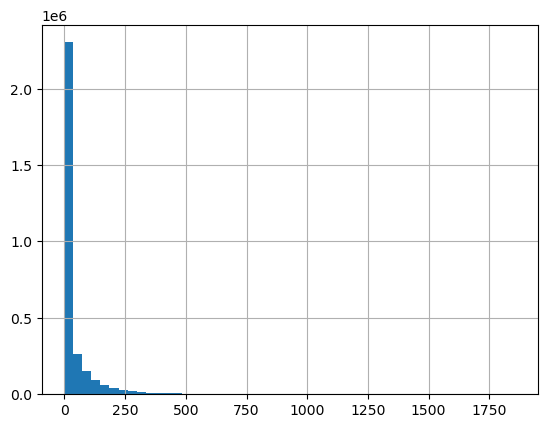

In [36]:
df_sai['Salidas'].hist(bins=50)

A distribuição de saidas é muito semelhante à das validações, com forte assimetria à direita.

<Axes: >

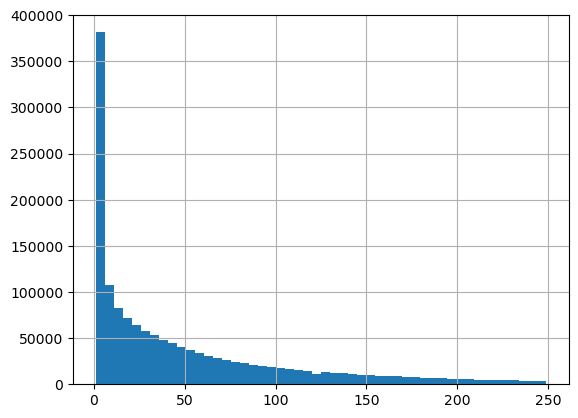

In [37]:
df_sai[(df_sai['Salidas'] < 250) & (df_sai['Salidas'] != 0)]['Salidas'].hist(bins=50)

**CHOOSING THE TRUNK LINE 'ZONA L CARRERA 10'**

Now, I must choose one trunk line ('Línea') for my future plans in this project, so let's check which is the one with the biggest number of validations or exits:

In [38]:
df_val.groupby('Línea')['Validaciones'].agg(['sum', 'mean', 'max']).sort_values(by='sum', ascending=False)

,sum,mean,max
Línea,,,
(30) Zona G NQS Sur,9700464.0,42.425318,1486.0
(34) Zona H Caracas Sur,9561343.0,28.770715,1129.0
(31) Zona F Av. Américas,8523975.0,43.209468,1818.0
(32) Zona C Av. Suba,7085783.0,39.502623,1215.0
(12) Zona L Carrera 10,6939475.0,31.007207,1779.0
(35) Zona D Calle 80,6420942.0,36.072303,1779.0
(38) Zona E NQS Central,5515284.0,35.665544,984.0
(33) Zona B AutoNorte,4726070.0,52.692801,1103.0
(36) Zona A Caracas,2637172.0,44.704650,1072.0


In [39]:
df_val.groupby('Línea')['Estación'].nunique()

Línea
(11) Zona K Calle 26           7
(12) Zona L Carrera 10        10
(30) Zona G NQS Sur           16
(31) Zona F Av. Américas       9
(32) Zona C Av. Suba          14
(33) Zona B AutoNorte          8
(34) Zona H Caracas Sur       18
(35) Zona D Calle 80          14
(36) Zona A Caracas            4
(37) Zona J Eje Ambiental      2
(38) Zona E NQS Central       11
(39) Zona F Calle 13           6
(40) Zona T Ciudad Bolívar     4
Name: Estación, dtype: int64

Now for the exits.

In [40]:
df_sai.groupby('Linea')['Salidas'].agg(['sum', 'mean', 'max']).sort_values(by='sum', ascending=False)

,sum,mean,max
Linea,,,
(33)Zona B AutoNorte,17863057,52.297067,1857
(30)Zona G NQS Sur,15458373,41.897038,1618
(34)Zona H Caracas Sur,14130904,33.964029,1205
(36)Zona A Caracas,11140722,60.555301,1673
(12)Zona L Carrera 10,10393859,33.153198,1579
(31)Zona F Av. Américas,10363769,42.622945,1608
(38)Zona E NQS Central,8672053,37.167110,1228
(11)Zona K Calle 26,8571287,34.380313,1287
(32)Zona C Av. Suba,8376911,34.310088,1041


In [41]:
df_sai.groupby('Linea')['Estacion'].nunique()

Linea
(11)Zona K Calle 26              15
(12)Zona L Carrera 10            11
(21)Line for Intermedium Gate     2
(30)Zona G NQS Sur               17
(31)Zona F Av. Américas          10
(32)Zona C Av. Suba              14
(33)Zona B AutoNorte             16
(34)Zona H Caracas Sur           18
(35)Zona D Calle 80              14
(36)Zona A Caracas               10
(37)Zona J Eje Ambiental          2
(38)Zona E NQS Central           13
(39)Zona F Calle 13               7
(40)Zona T Ciudad Bolívar         5
Name: Estacion, dtype: int64

The trunk line **Zona L Carrera 10** is fifth in number of entries and exits, and we also have information available from all of its 10 stations (other trunk lines appear to have a lot of stations temporarily closed due to the metro construction). So I will choose to work with this line from this point forward.

In [42]:
# Filter the datasets to only have data from the Zona L Carrera 10 trunk line
df_val10 = df_val[df_val['Línea'].str.contains('Zona L Carrera 10')]
print(df_val10.shape)

df_sai10 = df_sai[df_sai['Linea'].str.contains('Zona L Carrera 10')]
print(df_sai10.shape)

df_val10.head(3)

(223802, 6)
(313510, 5)


,Fase,Línea,Estación,Acceso de Estación,Fecha,Validaciones
1085,Fase 3,(12) Zona L Carrera 10,(10000) Portal 20 de Julio,(01) ALIMENTACIÓN JUAN REY/ALTAMIRA/TIHUAQUE/L...,2025-10-01 03:15:00,0.0
1086,Fase 3,(12) Zona L Carrera 10,(10000) Portal 20 de Julio,(01) ALIMENTACIÓN JUAN REY/ALTAMIRA/TIHUAQUE/L...,2025-10-01 03:45:00,18.0
1087,Fase 3,(12) Zona L Carrera 10,(10000) Portal 20 de Julio,(01) ALIMENTACIÓN JUAN REY/ALTAMIRA/TIHUAQUE/L...,2025-10-01 04:00:00,230.0


In [43]:
df_sai10.groupby('Estacion')['Acceso_Estacion'].nunique()

Estacion
(10000)Portal 20 de Julio             9
(10001)Country Sur                    4
(10002)Av. Primero de Mayo            8
(10003)Ciudad Jardín                  2
(10004)Policarpa                      4
(10005)Bicentenario                   9
(10006)SAN VICTORINO - NEOS CENTRO    5
(10007)Las Nieves                     4
(10008)San Diego                      5
(10009)Museo Nacional - FNG           4
(10010)San Bernardo                   4
Name: Acceso_Estacion, dtype: int64

Now, we need to transform the datasets to wide format, so that each station corresponds to one column. We can see that all stations have multiple entrances (Acceso_Estacion), so we need to aggregate all entrances, so we have only one value of the number of entries or exits, for each Date - Estacion combination. 

In [44]:
# Pivot table with aggfunc='sum'
df_wide_val = df_val10.pivot_table(index='Fecha', columns='Estación', values='Validaciones', aggfunc='sum').sort_index()
df_wide_sai = df_sai10.pivot_table(index='Fecha', columns='Estacion', values='Salidas',aggfunc='sum').sort_index()

In [45]:
# Check how many rows we have left
print(df_wide_val.shape)
print(df_wide_sai.shape)

(5155, 10)
(5460, 11)


In [46]:
# Check min and max timestamps
print(df_wide_val.index.min())
print(df_wide_val.index.max())

print(df_wide_sai.index.min())
print(df_wide_sai.index.max())


2025-10-01 00:00:00
2025-11-30 23:45:00
2025-10-01 00:00:00
2025-11-30 23:45:00


In [47]:
# Create missing timestamps. We need 15 min intervals for the whole 24 hours
df_wide_val = df_wide_val.asfreq('15min')
df_wide_sai = df_wide_sai.asfreq('15min')

In [48]:
# Check how many rows we have left
print(df_wide_val.shape)
print(df_wide_sai.shape)
print(df_wide_val.index.nunique())
print(df_wide_sai.index.nunique())


(5856, 10)
(5856, 11)
5856
5856


Let's add a column that indicates holidays and another one that indicates the day of the week. These will be used as exogenous variables.

In [49]:
import holidays

co_holidays = holidays.Colombia()

# Column with True or False for holidays
df_wide_val['Feriado'] = [date in co_holidays for date in df_wide_val.index.date]

# Column with 1 and 0 for holidays
df_wide_val['Feriado'] = df_wide_val['Feriado'].astype(int)

# Column with day of the week: monday=0 to sunday=6
df_wide_val['Dia_semana'] = df_wide_val.index.weekday

# Just to check for correctness, let's verify that the only holidays in october and november of 2025 are 13/oct, 3/nov and 17/nov
print(set(df_wide_val[df_wide_val.Feriado == 1].index.date))

df_wide_val['Feriado'] = df_wide_val['Feriado'].astype(int)
df_wide_val.head(3)

{datetime.date(2025, 11, 17), datetime.date(2025, 11, 3), datetime.date(2025, 10, 13)}


Estación,(10000) Portal 20 de Julio,(10001) Country Sur,(10002) Av. Primero de Mayo,(10003) Ciudad Jardín,(10004) Policarpa,(10005) Bicentenario,(10006) SAN VICTORINO - NEOS CENTRO,(10007) Las Nieves,(10008) San Diego,(10010) San Bernardo,Feriado,Dia_semana
Fecha,,,,,,,,,,,,
2025-10-01 00:00:00,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,0.0,0.0,0,2
2025-10-01 00:15:00,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2
2025-10-01 00:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2


In [50]:
# Same process for the exits dataframe

# Column with True or False
df_wide_sai['Feriado'] = [date in co_holidays for date in df_wide_sai.index.date]

# Column with 1 and 0 for holidays
df_wide_sai['Feriado'] = df_wide_sai['Feriado'].astype(int)

# Column with day of the week: monday=0 to sunday=6
df_wide_sai['Dia_semana'] = df_wide_sai.index.weekday

df_wide_sai.head(3)

Estacion,(10000)Portal 20 de Julio,(10001)Country Sur,(10002)Av. Primero de Mayo,(10003)Ciudad Jardín,(10004)Policarpa,(10005)Bicentenario,(10006)SAN VICTORINO - NEOS CENTRO,(10007)Las Nieves,(10008)San Diego,(10009)Museo Nacional - FNG,(10010)San Bernardo,Feriado,Dia_semana
Fecha,,,,,,,,,,,,,
2025-10-01 00:00:00,83.0,6.0,21.0,0.0,4.0,13.0,11.0,0.0,5.0,6.0,0.0,0,2
2025-10-01 00:15:00,38.0,2.0,9.0,0.0,2.0,11.0,5.0,0.0,3.0,0.0,2.0,0,2
2025-10-01 00:30:00,24.0,0.0,5.0,0.0,0.0,3.0,2.0,1.0,2.0,0.0,2.0,0,2


 Create the binary column 'Operativo', with 0 indicating the system is out of the operating hours and 1 indicating the system is operational. The stations are usually open a little before and a little after the operational hours of the routes, so let's generalize the operating window going from 3:45 am to 11:45 pm for entries. During this operating window there can not be any NaN values, but I will keep the NaNs out of the hours of operation.

In [51]:
import datetime

hora_min = datetime.time(3, 45, 0)
hora_max = datetime.time(23, 45, 0)

df_wide_val['Operativo'] = [1 if t >= hora_min and t <= hora_max else 0 for t in df_wide_val.index.time]

In [52]:
# For the entries dataframe: Fill all NaNs between 3:45:00 and 23:30:00. In the out of service hours, I will keep the NaN values.
df_nan = df_wide_val[df_wide_val['Operativo']==1]
print(set(df_nan[(df_nan.isna().any(axis=1))].index.time))
df_nan.isna().sum()

{datetime.time(23, 15), datetime.time(23, 45), datetime.time(3, 45), datetime.time(23, 30)}


Estación
(10000) Portal 20 de Julio               0
(10001) Country Sur                     61
(10002) Av. Primero de Mayo              0
(10003) Ciudad Jardín                   91
(10004) Policarpa                      122
(10005) Bicentenario                    61
(10006) SAN VICTORINO - NEOS CENTRO     61
(10007) Las Nieves                      61
(10008) San Diego                       90
(10010) San Bernardo                     0
Feriado                                  0
Dia_semana                               0
Operativo                                0
dtype: int64

In [53]:
df_wide_val.columns

Index(['(10000) Portal 20 de Julio', '(10001) Country Sur',
       '(10002) Av. Primero de Mayo', '(10003) Ciudad Jardín',
       '(10004) Policarpa', '(10005) Bicentenario',
       '(10006) SAN VICTORINO - NEOS CENTRO', '(10007) Las Nieves',
       '(10008) San Diego', '(10010) San Bernardo', 'Feriado', 'Dia_semana',
       'Operativo'],
      dtype='object', name='Estación')

In [54]:
# Boolean mask to fill nan's only during the operational window
mask = (df_wide_val.index.time >= hora_min) & (df_wide_val.index.time <= hora_max)
df_wide_val.loc[mask] = df_wide_val.fillna(0.0)

# Change any number in the out of service window to a null NaN value
mask1 = (df_wide_val.index.time < hora_min) | (df_wide_val.index.time > hora_max)
df_wide_val.loc[mask1] = np.nan

# Change the order of the columns in the dataframe so the stations are in geographical order
new_order = ['(10000) Portal 20 de Julio', '(10001) Country Sur',
              '(10002) Av. Primero de Mayo', '(10003) Ciudad Jardín',
              '(10004) Policarpa', '(10010) San Bernardo', '(10005) Bicentenario',
              '(10006) SAN VICTORINO - NEOS CENTRO', '(10007) Las Nieves',
              '(10008) San Diego', 'Feriado', 'Dia_semana',
              'Operativo']
df_wide_val = df_wide_val.reindex(columns=new_order)

# Save new dataframe to a csv file
df_wide_val.to_csv('../data/validaciones.csv', index=True, encoding='utf-8')

**PLOTTING THE TIME SERIES**

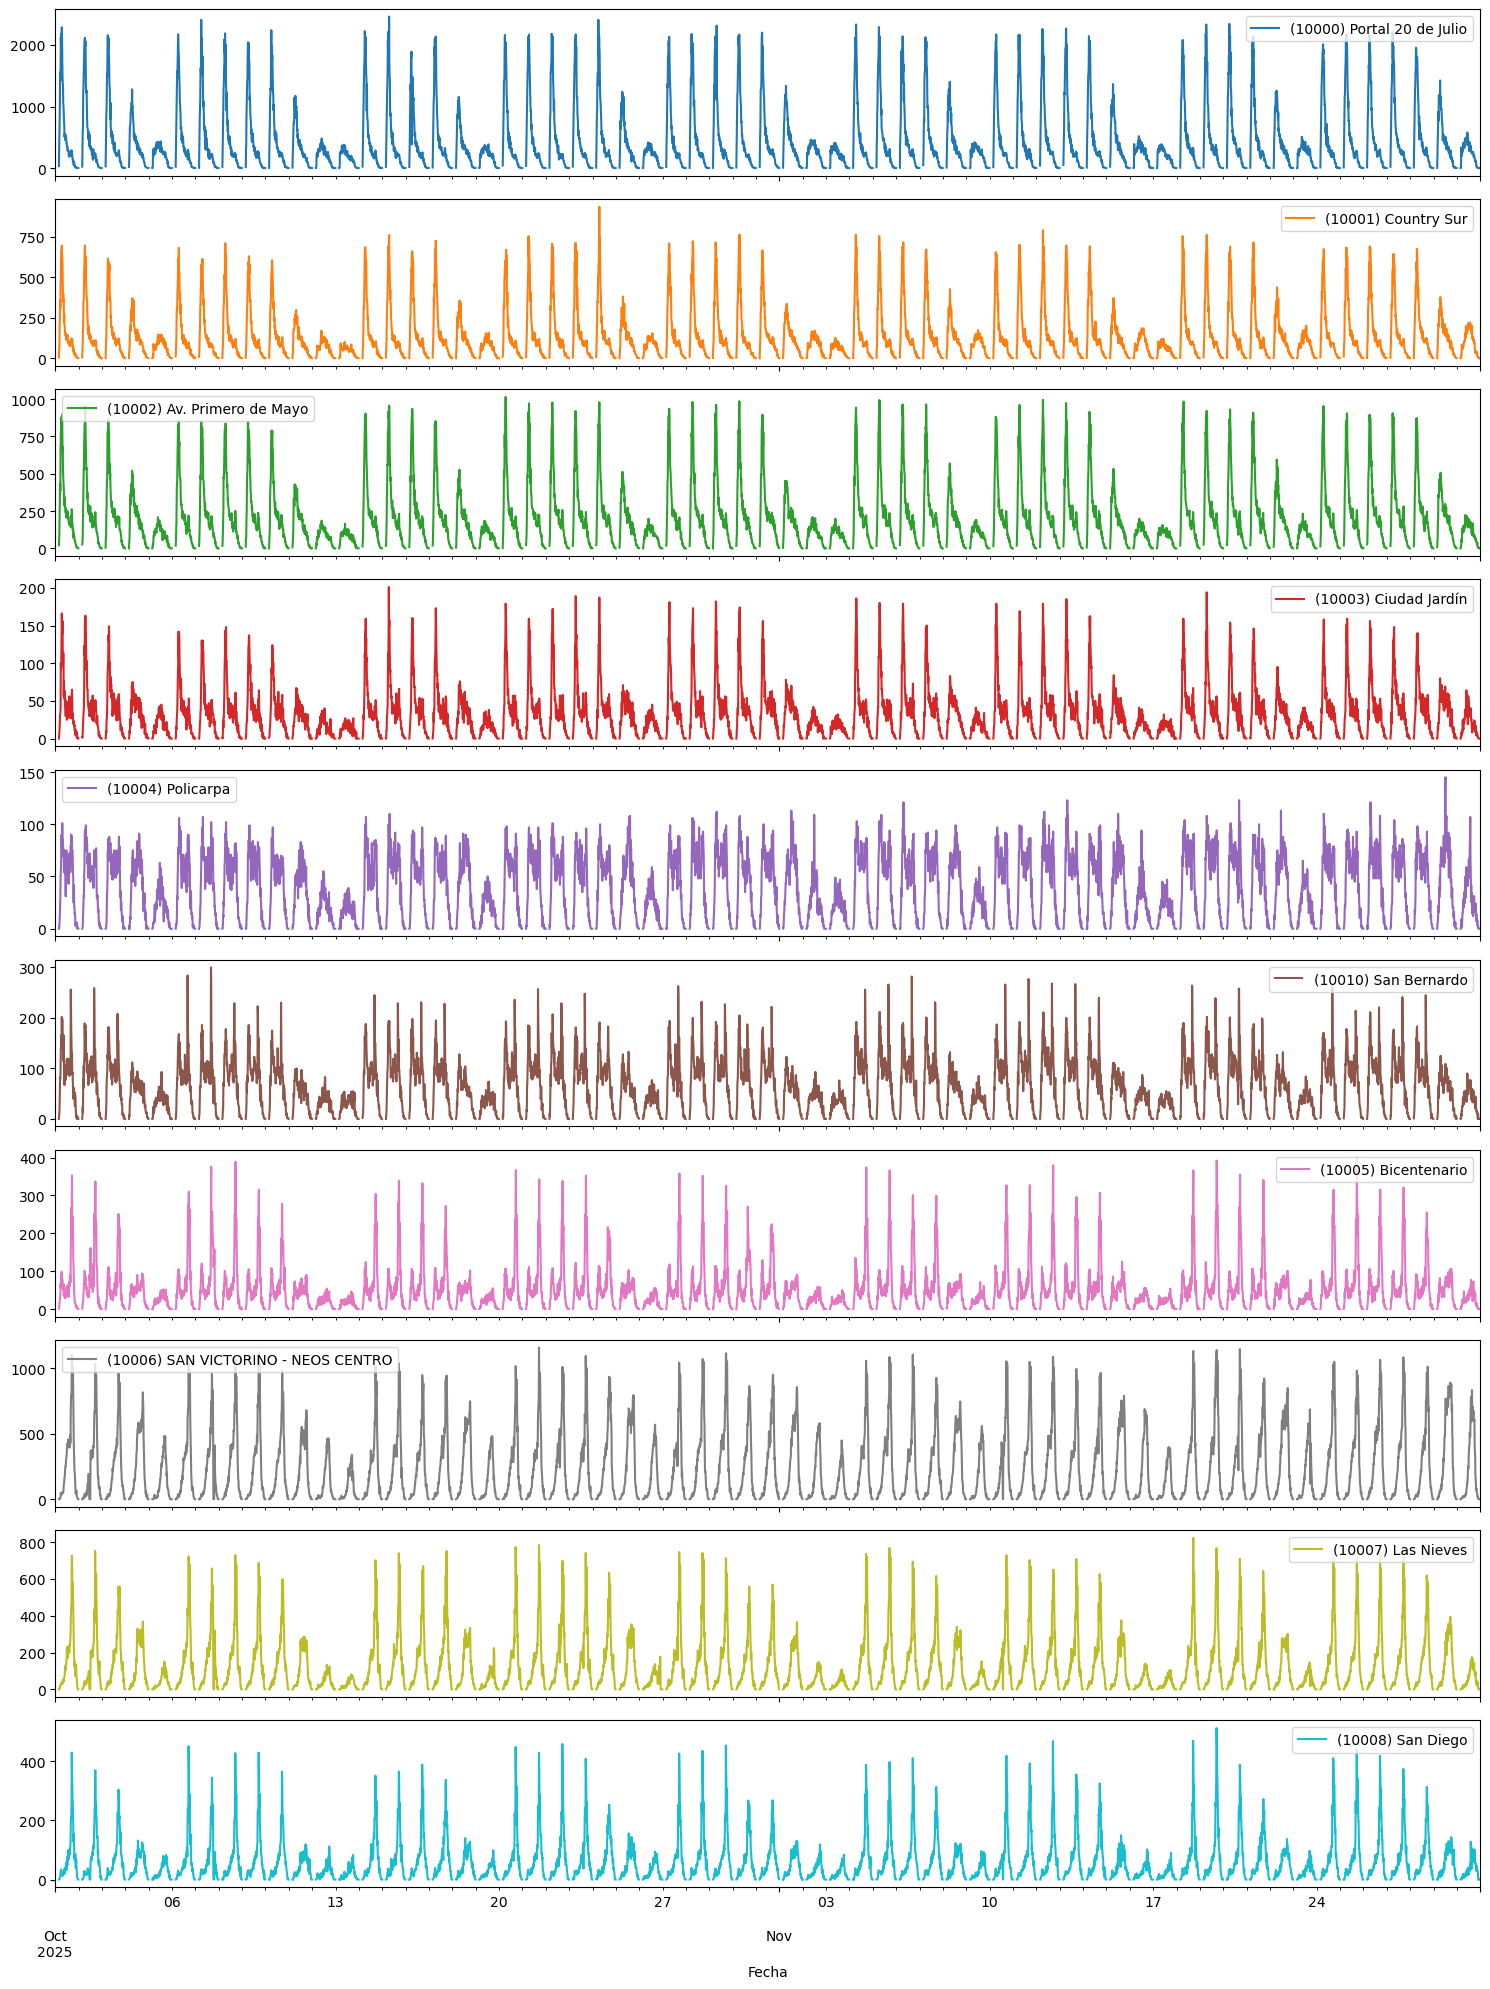

In [55]:
# Entries (validations) per station in the trunk line Carrera 10
df_wide_val.iloc[:, 0:10].plot(subplots=True, figsize=(15, 20), layout=(10, 1))
plt.tight_layout()
plt.show()

The graphs are ordered according to the geographical location of the stations and it's interesting that we can see a pattern in the spikes: In the Portal 20 de Julio and the subsequent stations, we can see spikes going up fast very early every morning, and going down in a more controled way throughout the day. The stations that are in the middle of the trunk show a bimodal pattern, and the last stations show again a notorious spike but towards the end of the day. This corresponds to the fact that the Portal and the first stations are located in areas of the city that are mostly residential, while the last ones are located towards/in the city center, where a lot of people have their workplaces. So, spikes in the morning are due to people leaving for work, and spikes in the evening are due to people going back to their homes from the city center.

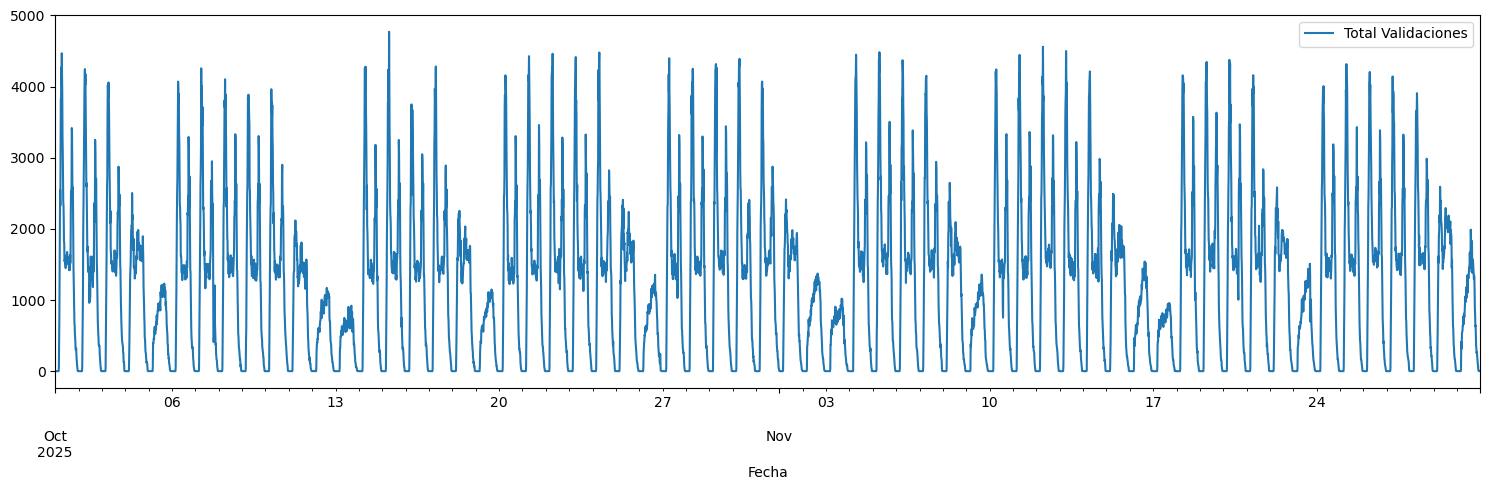

In [69]:
# Global time series for the trunk line 'Carrera 10'
df_wide_val['Total Validaciones'] = df_wide_val.iloc[:, 0:10].sum(axis=1)
df_total = df_wide_val[['Total Validaciones']]
df_total.plot(subplots=True, figsize=(15, 5))
plt.tight_layout()
plt.show()


We can clearly see that the number of validations (and therefore users) in the system decreases significantly in the weekends and holidays (for example october 13th and november 3rd and 17th were holiday mondays)